Num GPUs Available:  1
GPU is available, using GPU for training.
Found 27011 images belonging to 2 classes.
Found 4766 images belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization_94 (Bat  (None, 256)              1024      
 chNormalization)                          

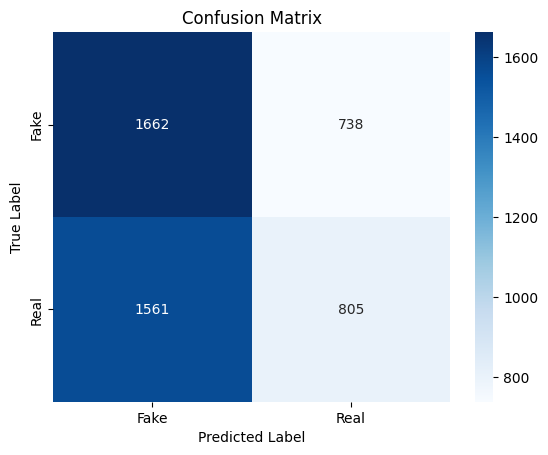

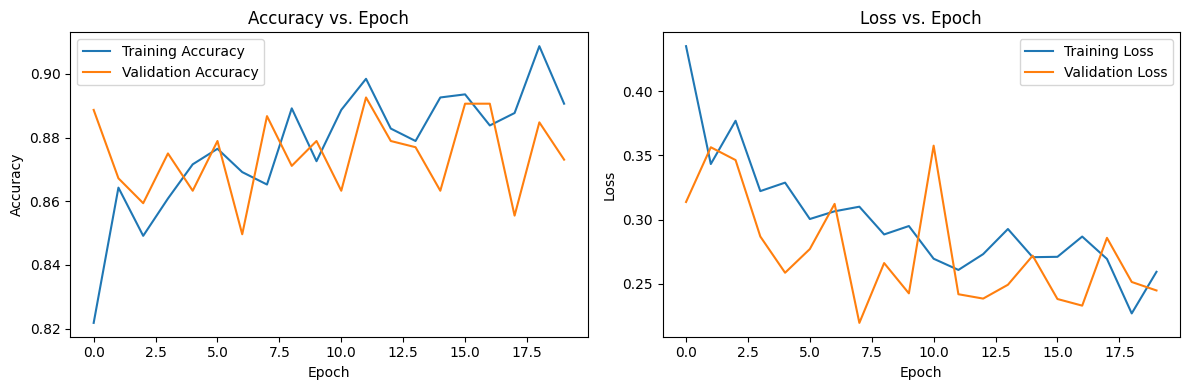

Found 8506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
532/532 [==============================] - 46s 84ms/step


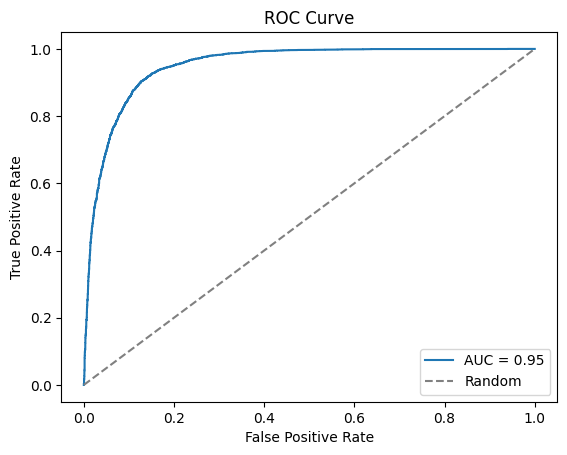

optimal threshold =  0.8370163
Classification Report:
              precision    recall  f1-score   support

        Fake       0.89      0.87      0.88      4037
        Real       0.89      0.90      0.90      4469

    accuracy                           0.89      8506
   macro avg       0.89      0.89      0.89      8506
weighted avg       0.89      0.89      0.89      8506

Confusion Matrix:
[[3527  510]
 [ 436 4033]]


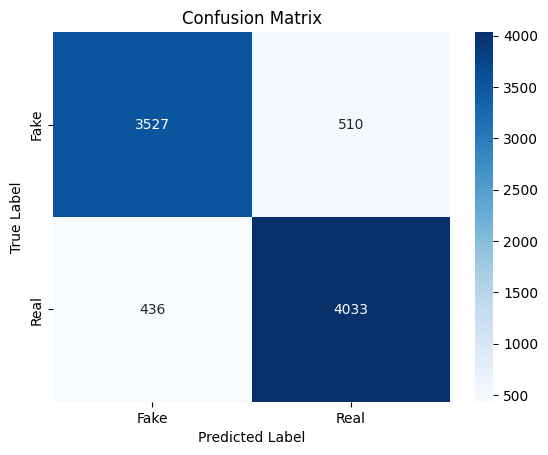

Evaluation Metrics:


AttributeError: 'tuple' object has no attribute 'items'

In [1]:
import model_fit_evaluate  
from tensorflow.keras.applications import ResNet50V2, InceptionV3, EfficientNetB2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_input_resnet50v2
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_input_inceptionv3
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_efficientnetb2
import tensorflow as tf
import os 
import telebot

if __name__ == '__main__':

    data_dir = '../balanced_data/train'
    image_size = (224, 224)
    batch_size = 4 
    epochs = 20

    train_generator, validation_generator = model_fit_evaluate.create_data_generators(data_dir, image_size, batch_size, preprocessing_function=preprocess_input_inceptionv3)

    model = model_fit_evaluate.create_custom_model(
    base_model=InceptionV3, 
    weights="imagenet",  
    input_shape=(224, 224, 3), 
    num_classes=1, 
    trainable_base=False 
    )

    history = model_fit_evaluate.train_model(model, train_generator, validation_generator, epochs, batch_size, early_stopping_patience=7, reduce_lr_patience=4, reduce_lr_factor=0.2)

    model_fit_evaluate.evaluate_model(model, validation_generator)

    model_fit_evaluate.plot_training_history(history)
    
    test_data_dir = '../balanced_data/test'

    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, test_data_dir, preprocess_input_inceptionv3, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics[0].items():
        print(f"{metric}: {value}")


In [3]:

    print("Evaluation Metrics:")
    for metric, value in metrics[0].items():
        print(f"{metric}: {value}")

Evaluation Metrics:
accuracy: 0.8887843874911827
precision: 0.8899823366136765
recall: 0.8736685657666584
f1_score: 0.88175
auc: 0.9501076776226262


In [2]:
 model.save('InceptionV3_Deepfake.keras')